In [3]:
from typing import TypedDict


class State(TypedDict):
    customer_name: str
    my_age: int | None


state: State = {"customer_name": "", "my_age": 0}
customer_name = state.get("customer_name")
print(customer_name)

In [4]:
def node_1(state: State):
    if not state.get("customer_name"):
        return {}

    return {"customer_name": "Wilmar"}

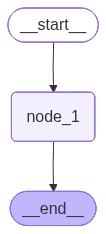

+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
  +--------+   
  | node_1 |   
  +--------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


In [6]:
from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph

builder = StateGraph(State)
builder.add_node("node_1", node_1)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

agent = builder.compile()

display(Image(agent.get_graph().draw_mermaid_png()))
print(agent.get_graph().draw_ascii())